# 02_modeling

### Problem Framing and Modeling Objective

The goal of this analysis is to predict biomass as a function of environmental and physicochemical variables in a controlled cultivation system. Given the biological nature of the process, the model is intended for **predictive purposes rather than strict causal inference**, allowing the inclusion of variables that may partially reflect the internal state of the system.

---

### Considerations on Variable Dependencies

It is important to note that several predictors, particularly nitrate (NO₃), oxygen (O₂), and carbon dioxide (CO₂), are not fully independent inputs. Instead, they are dynamically linked to biomass through biological processes such as nutrient uptake and gas exchange. As biomass increases, nitrate levels typically decrease due to consumption, while gas concentrations vary as a result of photosynthetic and respiratory activity.

As a result, some variables capture both **driving factors and system responses**, introducing dependencies among predictors. This characteristic is intrinsic to biological systems and must be considered when interpreting model outputs.

---

### Feature Selection and Handling of Multicollinearity

Exploratory analysis revealed strong correlations among several variables, indicating the presence of multicollinearity. While tree-based models such as Random Forest and XGBoost are generally robust to correlated inputs, feature selection was performed to improve model simplicity, stability, and interpretability.

The final feature set included:

- Irradiance  
- Nitrate concentration (NO₃)  
- Temperature  
- Dissolved Oxygen (OD)  
- Conductivity  

with biomass defined as the target variable.

These variables were selected to capture the key biological and environmental drivers of biomass production. NO₃ represents nutrient availability, a primary limiting factor for growth, while temperature and irradiance reflect metabolic and photosynthetic activity. Dissolved oxygen (OD) provides insight into oxygen dynamics and metabolic balance within the culture, and conductivity captures changes in ionic composition associated with nutrient uptake.

Highly correlated variables such as oxygen gas (O₂), carbon dioxide (CO₂), and pH were excluded due to their strong correlations with NO₃ and biomass. These variables largely reflect overlapping biological processes (e.g., gas exchange and metabolic activity), and their inclusion would introduce redundancy without significantly improving predictive performance.

By retaining a subset of less collinear and biologically meaningful variables, the model achieves a better balance between predictive accuracy, interpretability, and generalization.

---

### Modeling Strategy

Given the presence of non-linear relationships and interactions between variables, the modeling strategy prioritized a combination of linear and non-parametric approaches. Three models were implemented and compared:

- Linear Regression (baseline model)  
- Random Forest  
- XGBoost  

Linear Regression was used as a benchmark to establish a baseline performance and provide interpretability through model coefficients. In contrast, Random Forest and XGBoost were selected for their ability to capture complex, non-linear relationships and interactions among variables.

For the tree-based models, hyperparameter tuning was performed using GridSearchCV to identify the optimal combination of parameters. This process systematically evaluated multiple configurations (e.g., number of trees, depth, learning rate, and subsampling parameters) using cross-validation, ensuring robust model selection and improved generalization performance.

By comparing these models using RMSE and R² as evaluation metrics, the analysis assesses the trade-off between interpretability and predictive performance, while ensuring that the final model choice is supported by empirical results.

---

### Key Assumption

The model is designed with a predictive focus, where the primary objective is accurate estimation of biomass rather than causal interpretation of individual variables. Therefore, the inclusion of variables that partially reflect the system state is considered acceptable, as long as their role is properly acknowledged when interpreting results.

---

### 1.  Import Packages

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import matplotlib.pyplot as plt
import seaborn as sns

---

### 2. Loading the dataset

In [2]:
df = pd.read_csv("Verrucodesmus_verrucosus.csv")

---

#### 3. Dataset Preparation: Feature Selection and Train-Test Split

In [3]:

features = [
    "Irradiance",
    "NO3",
    "Temperature",
    "OD",
    "Conductivity"
]

target = "Biomass"

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

---

### 4. Modeling

#### 4.1. Model 1. Multiple Linear Regression

##### 4.1.1 Linear Regression: Training and Evaluation

In [4]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression R2:", r2_lr)

Linear Regression RMSE: 0.17712369278459925
Linear Regression R2: 0.9596226549842829


#### 4.2. Model 2 — Random Forest

##### 4.2.1. Random Forest Hyperparameter Tuning using Grid Search

In [5]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 3, 5]
}

grid_rf = GridSearchCV(
    rf,
    param_grid_rf,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best RF params:", grid_rf.best_params_)
print("Best RF score:", grid_rf.best_score_)

Best RF params: {'max_depth': 10, 'min_samples_leaf': 3, 'n_estimators': 300}
Best RF score: 0.9836722536374427


##### 4.2.2 Random Forest Model Evaluation

In [6]:
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)


rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R2:", r2_rf)

Random Forest RMSE: 0.09936775399856754
Random Forest R2: 0.9872920531460857


#### 4.3. Model 3 — XGBoost

##### 4.3.1. XGBoost Hyperparameter Tuning using Grid Search

In [7]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    random_state=42,
    tree_method="hist",
    device="cpu"   
)

param_grid_xgb = {
    "n_estimators": [100, 300],
    "learning_rate": [0.03, 0.1],
    "max_depth": [3, 5],
    "subsample": [0.8, 1],
    "colsample_bytree": [0.8, 1]
}

grid_xgb = GridSearchCV(
    xgb,
    param_grid_xgb,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print("Best XGB params:", grid_xgb.best_params_)
print("Best XGB score:", grid_xgb.best_score_)

Best XGB params: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Best XGB score: 0.9825405434304502


##### 4.3.2 XGBoost Model Evaluation

In [8]:
# ✅ Use the best model
best_xgb = grid_xgb.best_estimator_

# Prediction
y_pred_xgb = best_xgb.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost RMSE:", rmse_xgb)
print("XGBoost R2:", r2_xgb)

XGBoost RMSE: 0.10724329109226383
XGBoost R2: 0.9851978531303288


---

### 5. Model Comparison and Selection

In [9]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "RMSE": [rmse_lr, rmse_rf, rmse_xgb],
    "R2": [r2_lr, r2_rf, r2_xgb]
})

results

,Model,RMSE,R2
0,Linear Regression,0.177124,0.959623
1,Random Forest,0.099368,0.987292
2,XGBoost,0.107243,0.985198


The model comparison shows a clear improvement in predictive performance when moving from the baseline Linear Regression model to the tree-based approaches. Linear Regression achieved an RMSE of 0.177 and an R² of 0.960, providing a solid baseline but with lower accuracy compared to the other models. Random Forest delivered the best overall performance, with the lowest RMSE (0.099) and the highest R² (0.987), indicating superior ability to capture the underlying relationships in the data. XGBoost also performed strongly, with an RMSE of 0.107 and an R² of 0.985, slightly underperforming compared to Random Forest but still significantly outperforming the linear model. Overall, these results suggest that non-linear models are better suited for this problem, likely due to the complex interactions between biological and environmental variables, with Random Forest emerging as the optimal model for this dataset.

---

### 6. Feature Importance Analysis (Random Forest)

This section examines the relative importance of each input variable in the Random Forest model to better understand their contribution to biomass prediction. By analyzing feature importance scores, we can identify which environmental and physicochemical factors have the greatest influence on the model’s predictions, providing insight into the underlying biological processes.

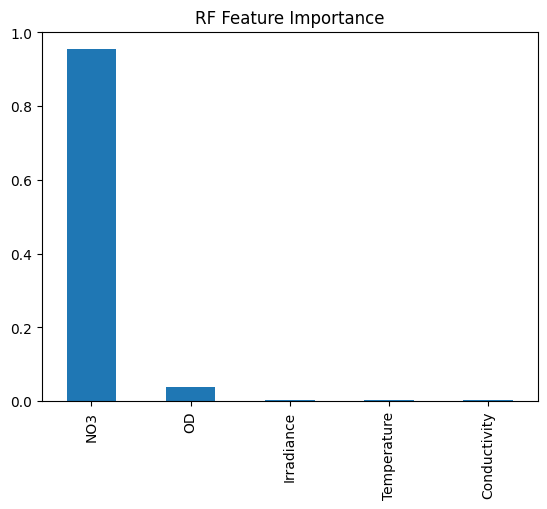

In [10]:
rf_importance = pd.Series(best_rf.feature_importances_, index=features).sort_values(ascending=False)

rf_importance.plot(kind="bar", title="RF Feature Importance")
plt.show()

In [11]:
importance = pd.Series(best_rf.feature_importances_, index=features)
importance.sort_values(ascending=False)

NO3             0.954233
OD              0.039300
Irradiance      0.002686
Temperature     0.002006
Conductivity    0.001775
dtype: float64

The feature importance results indicate that NO₃ is by far the dominant predictor, accounting for approximately 95% of the model’s importance, while all other variables contribute only marginally. Dissolved oxygen (OD) shows a small but noticeable effect (~4%), whereas irradiance, temperature, and conductivity have negligible influence on the model’s predictions. This suggests that biomass variability in the dataset is primarily driven by nitrate availability, reinforcing its role as a key limiting factor in the biological system.

From a biological perspective, these findings are consistent with known microalgal growth dynamics. The strong relationship between biomass and NO₃ reflects nutrient consumption during growth, while dissolved oxygen variations are associated with metabolic processes such as photosynthesis and respiration. Conductivity likely acts as an indirect indicator of changes in nutrient availability within the culture medium.

Overall, these results indicate that the model is effectively capturing the dynamic behavior of the system, with NO₃ acting as a proxy for the underlying biological processes rather than merely a static environmental variable.


---

### 7. Predicted vs. Actual Biomass (Random Forest Model)

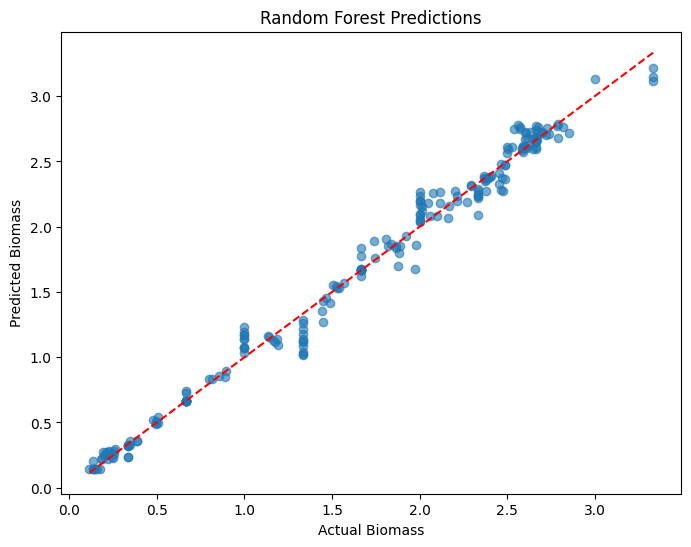

In [12]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf, alpha=0.6)
plt.xlabel("Actual Biomass")
plt.ylabel("Predicted Biomass")
plt.title("Random Forest Predictions")
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")
plt.show()

The plot compares predicted versus actual biomass values for the Random Forest model, showing how closely predictions align with the ideal diagonal (perfect prediction line). The points appear tightly clustered around this line, indicating strong predictive accuracy and low error, which is consistent with the high R² and low RMSE obtained previously. 

___________________________________________


📄 Model Limitations

While the model demonstrates high predictive performance, it is important to acknowledge its limitations. Several predictors are dynamically dependent on biomass, meaning that the model partially relies on variables that reflect the current state of the system rather than independent input conditions.

As a result, the model is best interpreted as a predictive tool rather than a causal model. Its predictions are highly accurate within the observed data distribution, but care must be taken when extrapolating to new experimental conditions where these relationships may differ.

